# CNN для классификации изображений одежды: от базовой модели к продвинутой

Целью этого ноутбука является:
- обучение базовой CNN на Fashion-MNIST
- улучшение её с помощью BatchNorm и Dropout
- добавление аугментации данных
- сравнение три подхода по метрикам качества

Обучаться нейросеть будет на датасете Fashion-MNIST — более сложной замене классического MNIST. В датасете 10 классов одежды вместо цифр, при том же разрешении (28×28). Это лучше показывает различия между архитектурами.

In [39]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
import torchvision.datasets as dsets
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import classification_report, confusion_matrix

torch.manual_seed(42)
np.random.seed(42)

## 1. Подготовка данных

In [40]:
IMAGE_SIZE = 28
BATCH_SIZE = 128
CLASS_NAMES = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

### Трансформации

Для базовой модели — только resize и нормализация.  
Для модели с аугментацией — добавляем случайные повороты и сдвиги. Однако стоит учитывать, что при малом разрешении (16×16) такие трансформации могут быть слишком агрессивными.

In [41]:
base_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

augmented_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1)),
    transforms.ToTensor(),
])

### Train | Validation | Test split

Из 60000 обучающих примеров выделяем 10000 на валидацию (подбор гиперпараметров).  
Тестовая выборка (10000) используется только для финальной оценки.

In [42]:
full_train = dsets.FashionMNIST(root='./data', train=True, transform=base_transform, download=True)
train_dataset, val_dataset = random_split(full_train, [50000, 10000],
                                          generator=torch.Generator().manual_seed(42))
test_dataset = dsets.FashionMNIST(root='./data', train=False, transform=base_transform, download=True)

# Для аугментированной модели — отдельный датасет с другим transform
full_train_aug = dsets.FashionMNIST(root='./data', train=True, transform=augmented_transform, download=True)
train_dataset_aug = random_split(full_train_aug, [50000, 10000],
                                  generator=torch.Generator().manual_seed(42))[0]

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

Train: 50000, Val: 10000, Test: 10000


### Примеры из датасета

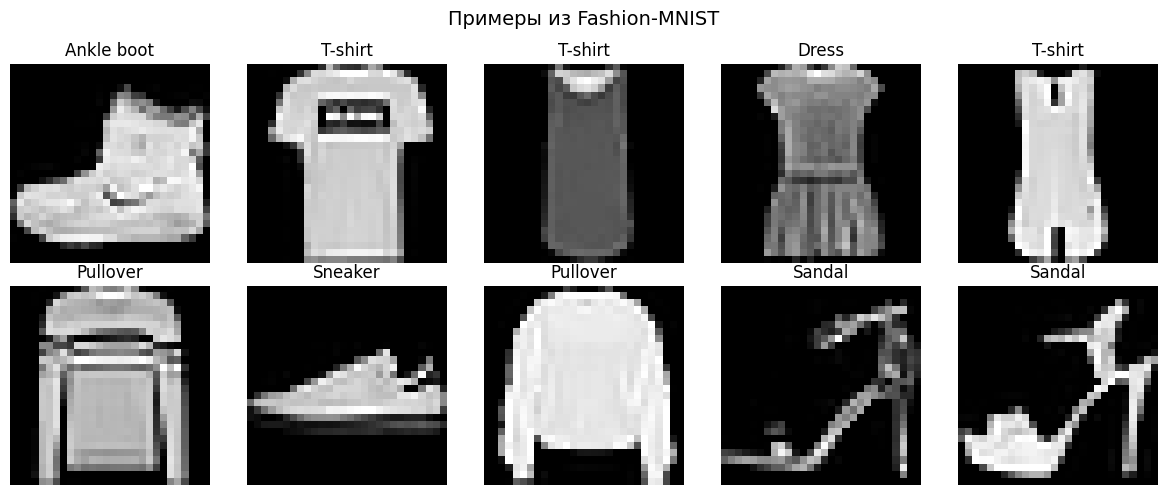

In [43]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    img, label = full_train[i]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(CLASS_NAMES[label])
    ax.axis('off')
plt.suptitle('Примеры из Fashion-MNIST', fontsize=14)
plt.tight_layout()
plt.show()

## 2. Архитектуры

### Baseline — простая CNN без регуляризации

Используем два свёрточных блока (Conv2d - ReLU - MaxPool2d) и один полносвязный слой. Регуляризацию добавлять не будем — ожидаем переобучение на поздних итерациях.

In [45]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.cnn1 = nn.Conv2d(1, 16, kernel_size=5, padding=2)
        self.maxpool1 = nn.MaxPool2d(kernel_size=2)
        self.cnn2 = nn.Conv2d(16, 32, kernel_size=5, padding=2)
        self.maxpool2 = nn.MaxPool2d(kernel_size=2)
        self.fc1 = nn.Linear(32 * 7 * 7, num_classes)

    def forward(self, x):
        x = torch.relu(self.cnn1(x))
        x = self.maxpool1(x)
        x = torch.relu(self.cnn2(x))
        x = self.maxpool2(x)
        x = x.view(x.size(0), -1)
        return self.fc1(x)

### BatchNorm + Dropout

BatchNorm стабилизирует обучение, Dropout (50% перед FC) регуляризирует.  
ставим `bias=False` в свёрточных слоях, поскольку его роль берёт на себя бета в BatchNorm.

In [46]:
class ImprovedCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

### Augmented — та же архитектура, но с аугментацией данных

Архитектура идентична ImprovedCNN — различие только в данных: обучающие изображения случайно поворачиваются и сдвигаются. Это должно помогать обобщению, но на малых разрешениях эффект может быть обратным.

## 3. Обучение

### Функция обучения

Принимает модель, данные, гиперпараметры. Возвращает историю обучения для последующего анализа.

In [50]:
def train_model(model, train_loader, val_loader, epochs=25, lr=0.01):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        # train
        model.train()
        train_loss = 0
        for x, y in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        history['train_loss'].append(train_loss / len(train_loader))

        # validation 
        model.eval()
        val_loss = 0
        correct = 0
        total = 0
        with torch.no_grad():
            for x, y in val_loader:
                z = model(x)
                val_loss += criterion(z, y).item()
                correct += (torch.argmax(z, 1) == y).sum().item()
                total += y.size(0)

        history['val_loss'].append(val_loss / len(val_loader))
        history['val_acc'].append(correct / total)

        if (epoch + 1) % 5 == 0:
            print(f"  Epoch {epoch+1:2d}/{epochs} | "
                  f"Train Loss: {history['train_loss'][-1]:.4f} | "
                  f"Val Loss: {history['val_loss'][-1]:.4f} | "
                  f"Val Acc: {history['val_acc'][-1]:.4f}")
            
        scheduler.step(val_loss/len(val_loader))

    return history

### Обучаем три модели

In [51]:
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

# baseline
print("Baseline CNN")
model_baseline = BaselineCNN()
train_loader_base = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
history_baseline = train_model(model_baseline, train_loader_base, val_loader, epochs=30, lr=0.001)

# Improved (batchNorm + dropout)
print('\n\n')
print("Improved CNN (BatchNorm + Dropout)")
model_improved = ImprovedCNN()
history_improved = train_model(model_improved, train_loader_base, val_loader, epochs=30, lr=0.001)

# Improved + augmentation
print('\n\n')
print("Improved CNN + Augmentation")
model_augmented = ImprovedCNN()
train_loader_aug = DataLoader(train_dataset_aug, batch_size=BATCH_SIZE, shuffle=True)
history_augmented = train_model(model_augmented, train_loader_aug, val_loader, epochs=30, lr=0.001)

Baseline CNN
  Epoch  5/30 | Train Loss: 0.2815 | Val Loss: 0.2853 | Val Acc: 0.8992
  Epoch 10/30 | Train Loss: 0.2185 | Val Loss: 0.2570 | Val Acc: 0.9078
  Epoch 15/30 | Train Loss: 0.1804 | Val Loss: 0.2398 | Val Acc: 0.9154
  Epoch 20/30 | Train Loss: 0.1473 | Val Loss: 0.2461 | Val Acc: 0.9138
  Epoch 25/30 | Train Loss: 0.1138 | Val Loss: 0.2362 | Val Acc: 0.9182
  Epoch 30/30 | Train Loss: 0.1005 | Val Loss: 0.2515 | Val Acc: 0.9179



Improved CNN (BatchNorm + Dropout)
  Epoch  5/30 | Train Loss: 0.2723 | Val Loss: 0.2350 | Val Acc: 0.9108
  Epoch 10/30 | Train Loss: 0.2180 | Val Loss: 0.2170 | Val Acc: 0.9206
  Epoch 15/30 | Train Loss: 0.1895 | Val Loss: 0.2076 | Val Acc: 0.9282
  Epoch 20/30 | Train Loss: 0.1643 | Val Loss: 0.1935 | Val Acc: 0.9307
  Epoch 25/30 | Train Loss: 0.1513 | Val Loss: 0.1925 | Val Acc: 0.9322
  Epoch 30/30 | Train Loss: 0.1380 | Val Loss: 0.1946 | Val Acc: 0.9353



Improved CNN + Augmentation
  Epoch  5/30 | Train Loss: 0.4480 | Val Loss: 0.3248 

## 4. Сравнение экспериментов

### Кривые обучения

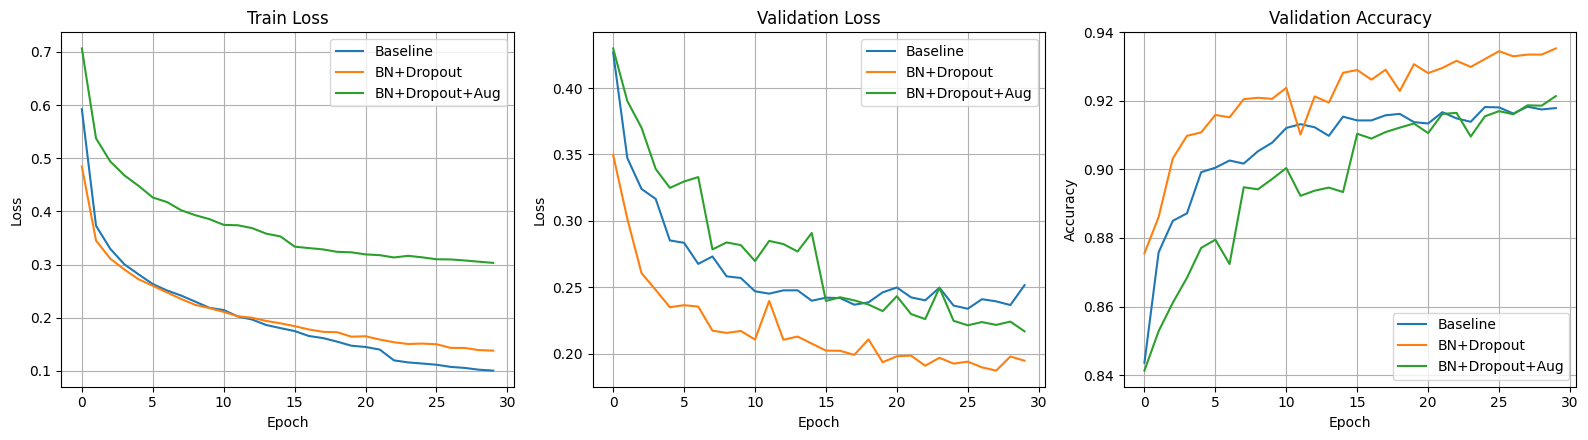

In [52]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 4.5))

# train Loss
for hist, name in [(history_baseline, 'Baseline'),
                    (history_improved, 'BN+Dropout'),
                    (history_augmented, 'BN+Dropout+Aug')]:
    ax1.plot(hist['train_loss'], label=name)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Train Loss')
ax1.legend()
ax1.grid(True)

# val loss
for hist, name in [(history_baseline, 'Baseline'),
                    (history_improved, 'BN+Dropout'),
                    (history_augmented, 'BN+Dropout+Aug')]:
    ax2.plot(hist['val_loss'], label=name)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title('Validation Loss')
ax2.legend()
ax2.grid(True)

# val accuracy
for hist, name in [(history_baseline, 'Baseline'),
                    (history_improved, 'BN+Dropout'),
                    (history_augmented, 'BN+Dropout+Aug')]:
    ax3.plot(hist['val_acc'], label=name)
ax3.set_xlabel('Epoch')
ax3.set_ylabel('Accuracy')
ax3.set_title('Validation Accuracy')
ax3.legend()
ax3.grid(True)

plt.tight_layout()
plt.show()

### Сводная таблица по валидации

In [53]:
print(f"{'Model':<25} {'Best Val Acc':>12} {'Final Train Loss':>17} {'Final Val Loss':>15}")
print("-" * 72)
for hist, name in [(history_baseline, 'Baseline'),
                    (history_improved, 'BN+Dropout'),
                    (history_augmented, 'BN+Dropout+Aug')]:
    best_acc = max(hist['val_acc'])
    print(f"{name:<25} {best_acc:>11.4f} {hist['train_loss'][-1]:>17.4f} {hist['val_loss'][-1]:>15.4f}")

Model                     Best Val Acc  Final Train Loss  Final Val Loss
------------------------------------------------------------------------
Baseline                       0.9183            0.1005          0.2515
BN+Dropout                     0.9353            0.1380          0.1946
BN+Dropout+Aug                 0.9214            0.3031          0.2168


## 5. Финальная оценка на тесте

In [54]:
def evaluate_on_test(model, test_loader):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for x, y in test_loader:
            preds = torch.argmax(model(x), 1)
            all_preds.append(preds)
            all_labels.append(y)
    return torch.cat(all_preds).numpy(), torch.cat(all_labels).numpy()

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

### Classification Report и Confusion Matrix для каждой модели

In [55]:
models = [
    (model_baseline, 'Baseline CNN'),
    (model_improved, 'Improved CNN (BN+Dropout)'),
    (model_augmented, 'Improved CNN + Augmentation'),
]

test_results = {}

for model, name in models:
    preds, labels = evaluate_on_test(model, test_loader)
    test_results[name] = (preds, labels)
    acc = (preds == labels).mean()
    print('\n\n')
    print(f"{name} — Test Accuracy: {acc:.4f}")
    print(classification_report(labels, preds, target_names=CLASS_NAMES, digits=4))




Baseline CNN — Test Accuracy: 0.9145
              precision    recall  f1-score   support

     T-shirt     0.8235    0.8910    0.8559      1000
     Trouser     0.9949    0.9830    0.9889      1000
    Pullover     0.8685    0.8650    0.8667      1000
       Dress     0.9037    0.9380    0.9205      1000
        Coat     0.8552    0.8680    0.8615      1000
      Sandal     0.9898    0.9720    0.9808      1000
       Shirt     0.7959    0.7060    0.7483      1000
     Sneaker     0.9426    0.9850    0.9633      1000
         Bag     0.9899    0.9780    0.9839      1000
  Ankle boot     0.9796    0.9590    0.9692      1000

    accuracy                         0.9145     10000
   macro avg     0.9144    0.9145    0.9139     10000
weighted avg     0.9144    0.9145    0.9139     10000




Improved CNN (BN+Dropout) — Test Accuracy: 0.9261
              precision    recall  f1-score   support

     T-shirt     0.8868    0.8540    0.8701      1000
     Trouser     0.9990    0.9870    0.

### Confusion Matrix лучшей модели

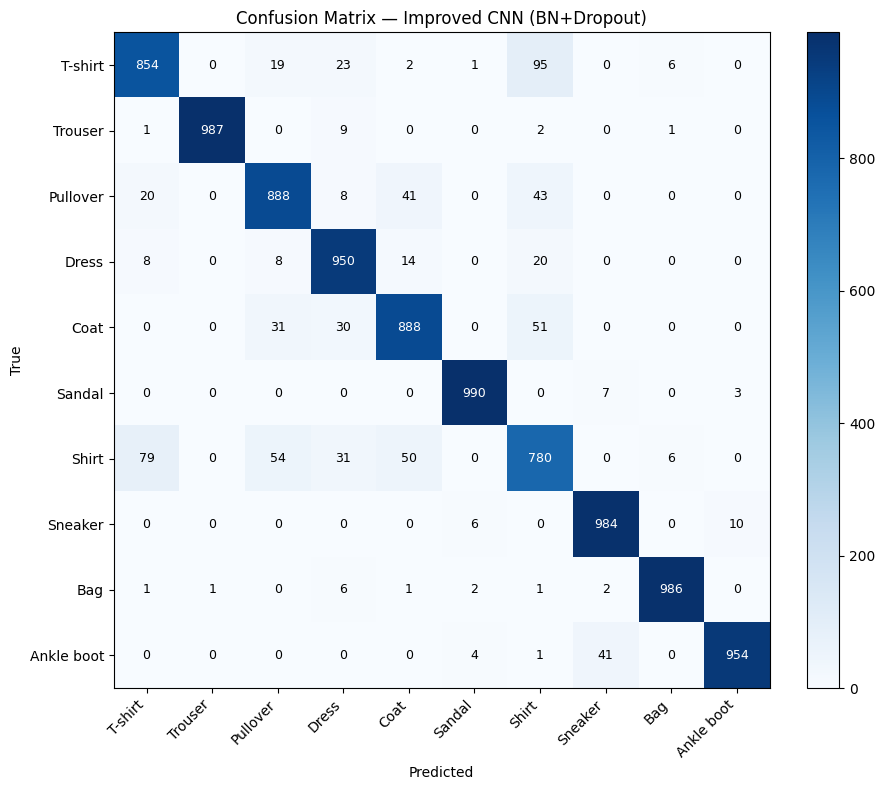

In [56]:
# Берём модель с лучшим test accuracy
best_name = max(test_results, key=lambda k: (test_results[k][0] == test_results[k][1]).mean())
preds, labels = test_results[best_name]

cm = confusion_matrix(labels, preds)
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, cmap='Blues')

for i in range(10):
    for j in range(10):
        color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
        ax.text(j, i, cm[i, j], ha='center', va='center', color=color, fontsize=9)

ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f'Confusion Matrix — {best_name}')
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

### Анализ ошибок

Посмотрим, какие классы модель путает чаще всего.

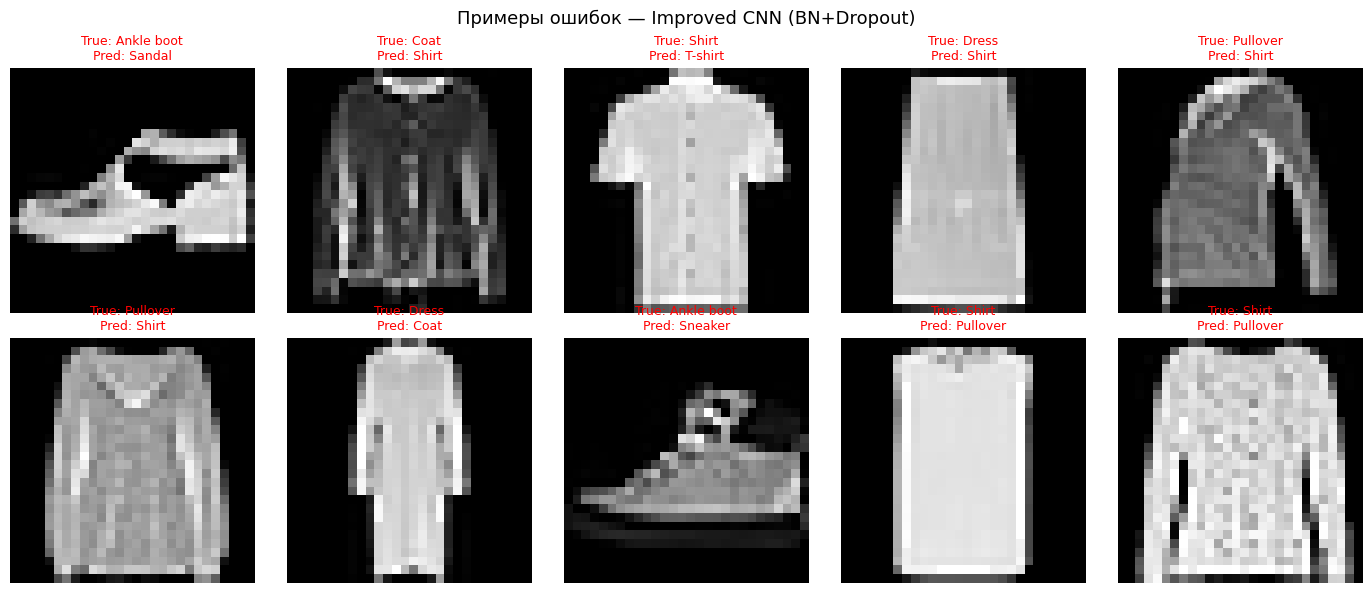


Всего ошибок: 739 из 10000 (7.4%)


In [57]:
preds, labels = test_results[best_name]
errors = np.where(preds != labels)[0]

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
    if i < len(errors):
        idx = errors[i]
        img = test_dataset[idx][0].squeeze()
        ax.imshow(img, cmap='gray')
        ax.set_title(f'True: {CLASS_NAMES[labels[idx]]}\nPred: {CLASS_NAMES[preds[idx]]}',
                     fontsize=9, color='red')
    ax.axis('off')
plt.suptitle(f'Примеры ошибок — {best_name}', fontsize=13)
plt.tight_layout()
plt.show()

print(f"\nВсего ошибок: {len(errors)} из {len(labels)} ({len(errors)/len(labels)*100:.1f}%)")

## 6. Визуализация фильтров

Посмотрим, какие паттерны выучили фильтры первого свёрточного слоя лучшей модели.

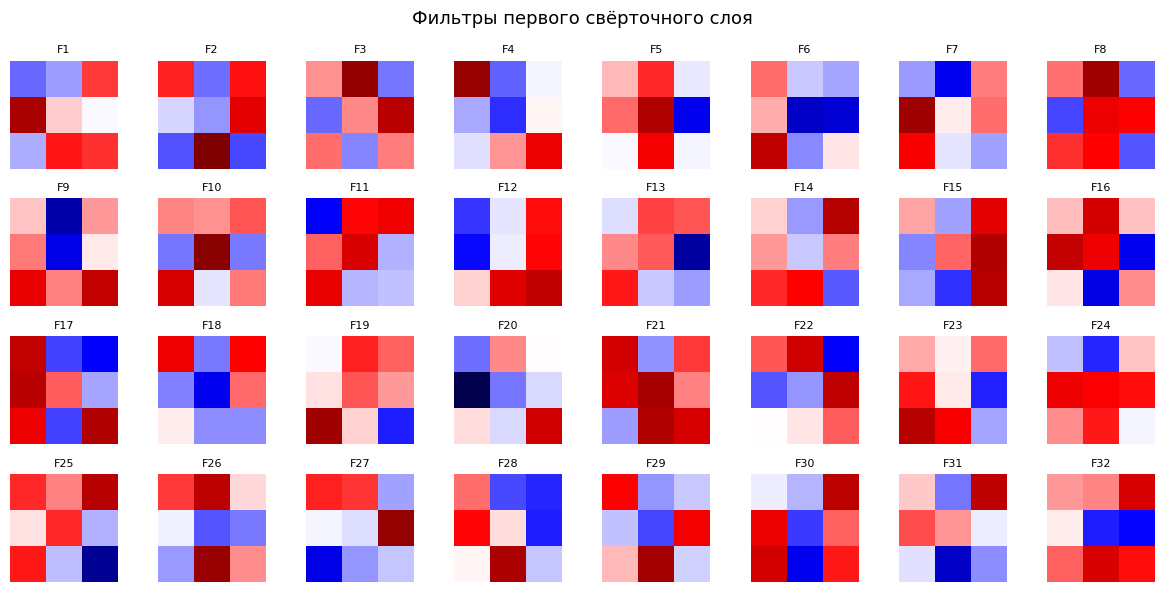

In [58]:
best_model = [m for m, n in models if n == best_name][0]

# Достаём веса первого conv слоя
if hasattr(best_model, 'features'):
    first_conv_weight = best_model.features[0].weight.data
else:
    first_conv_weight = best_model.cnn1.weight.data

n_filters = first_conv_weight.shape[0]
n_cols = 8
n_rows = (n_filters + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, n_rows * 1.5))
w_min = first_conv_weight.min().item()
w_max = first_conv_weight.max().item()

for i, ax in enumerate(axes.flat):
    if i < n_filters:
        ax.imshow(first_conv_weight[i, 0].numpy(), vmin=w_min, vmax=w_max, cmap='seismic')
        ax.set_title(f'F{i+1}', fontsize=8)
    ax.axis('off')

plt.suptitle('Фильтры первого свёрточного слоя', fontsize=13)
plt.tight_layout()
plt.show()

# Выводы

В ходе экспериментов были обучены три конфигурации CNN на датасете Fashion-MNIST: базовая модель без регуляризации, модель с BatchNorm и Dropout, а также та же архитектура с добавлением аугментации данных. Лучший результат показала модель с BatchNorm и Dropout — она достигла наибольшей accuracy на валидации при наименьшем val loss. BatchNorm стабилизировал обучение и позволил модели быстрее сходиться, а Dropout не дал ей переобучиться. Это хорошо видно по кривым обучения: train loss и val loss идут близко друг к другу, без характерного расхождения.

Базовая модель обучилась неплохо по train loss, но val loss после определённого момента начал расти — классическая картина переобучения. Модель запоминала тренировочные данные вместо того, чтобы выучить обобщённые признаки. Аугментация, вопреки ожиданиям, ухудшила результат. Причина в том, что Fashion-MNIST — уже стандартизированный датасет с центрированными изображениями одинакового масштаба. Повороты и сдвиги создавали варианты, которых нет в тестовых данных, и по сути мешали модели обучиться. Это важное наблюдение: аугментации полезны не всегда, их нужно подбирать под конкретные данные и условия задачи. По confusion matrix видно, что основные ошибки приходятся на визуально похожие классы — Shirt и T-shirt, Pullover и Coat, что объяснимо и при ручной классификации вызвало бы затруднения.